In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold,cross_val_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df=pd.read_csv("drug200.csv")

In [3]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [4]:
df.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [5]:
X=df.drop("Drug",axis=1)
y=df["Drug"]

In [6]:
categorical=["Sex","BP","Cholesterol"]
numerical=["Age","Na_to_K"]

In [7]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical),
    ("cat", OneHotEncoder(drop="first"), categorical)
])

In [8]:
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

In [9]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)


In [10]:
scores = cross_val_score(pipeline, X, y, cv=kfold, scoring="accuracy")

print("Accuracy for each fold:", scores)
print("Average Accuracy:", np.mean(scores))

Accuracy for each fold: [0.875 0.925 0.95  0.775 0.875]
Average Accuracy: 0.8800000000000001


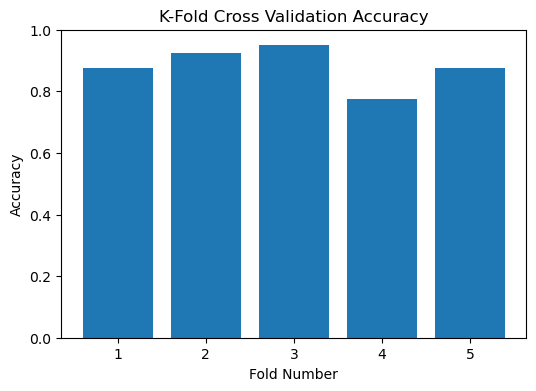

In [11]:
import matplotlib.pyplot as plt

fold_numbers = range(1, len(scores) + 1)

plt.figure(figsize=(6,4))
plt.bar(fold_numbers, scores)
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.title("K-Fold Cross Validation Accuracy")
plt.ylim(0, 1)
plt.show()

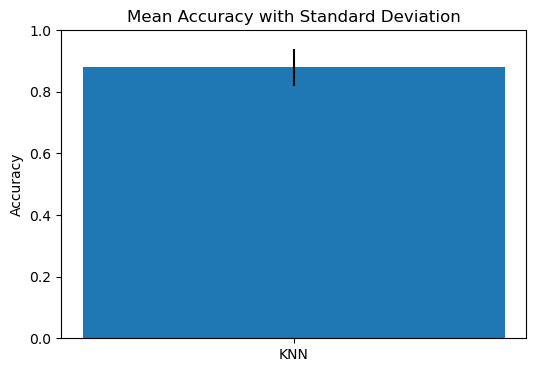

In [12]:
mean_score = np.mean(scores)
std_score = np.std(scores)

plt.figure(figsize=(6,4))
plt.bar(["KNN"], [mean_score], yerr=[std_score])
plt.ylabel("Accuracy")
plt.title("Mean Accuracy with Standard Deviation")
plt.ylim(0, 1)
plt.show()

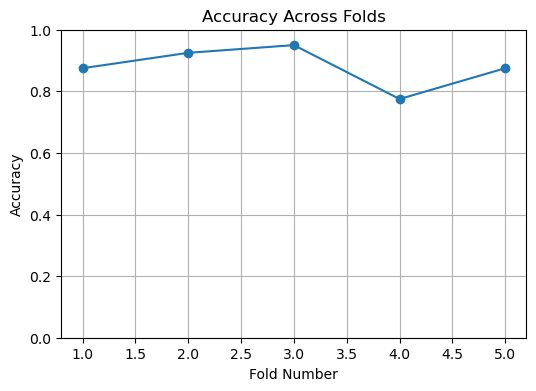

In [13]:
plt.figure(figsize=(6,4))
plt.plot(fold_numbers, scores, marker='o')
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.title("Accuracy Across Folds")
plt.ylim(0, 1)
plt.grid(True)
plt.show()